# Chapter 9 Numerical Excersises

In [1647]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

## 9.1

### a

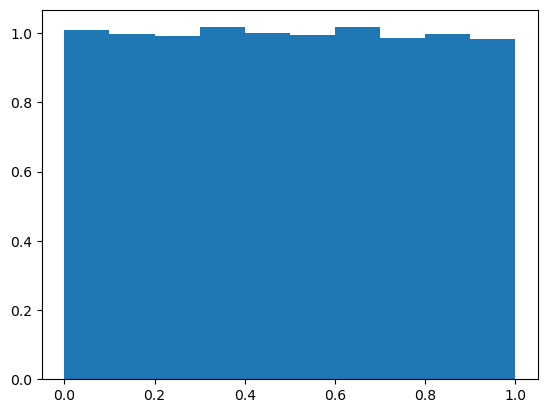

In [1648]:
sample = np.random.uniform(0, 1, 100000)
plt.hist(sample,density=True)
plt.show()

### b

In [1649]:
factor = sum(np.exp(-3.6 * sample))
proportional_sample = np.random.choice(sample,10000, p = np.exp(-3.6 * sample)/factor)


### c

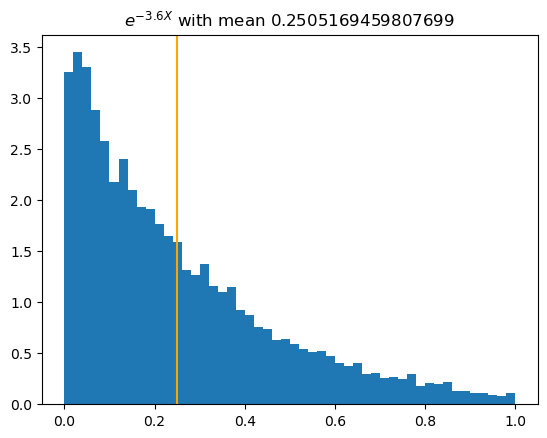

In [1650]:
plt.hist(proportional_sample, bins = 50, density=True)
plt.axvline(np.mean(proportional_sample), color = 'orange')
plt.title(fr'$e^{{-3.6X}}$ with mean {np.mean(proportional_sample)}')
plt.show()

## 9.2

### a

In [1651]:
diff = 0.01
x = np.arange(0,1 + diff, diff)

samples = np.random.normal(loc = 0, scale= m.sqrt(diff), size=(100000, len(x) - 1))

samples = np.insert(samples, 0, 0, axis=1)


BM = np.cumsum(samples, axis=1)

BM_tilde = BM + x


### b

In [1652]:
factor = sum(np.exp(-BM_tilde[:,-1] + 1/2))

proportional = np.random.choice(100000, 10000, p = np.exp(-BM_tilde[:,-1] + 1/2)/factor)

S = BM_tilde[proportional]

### c

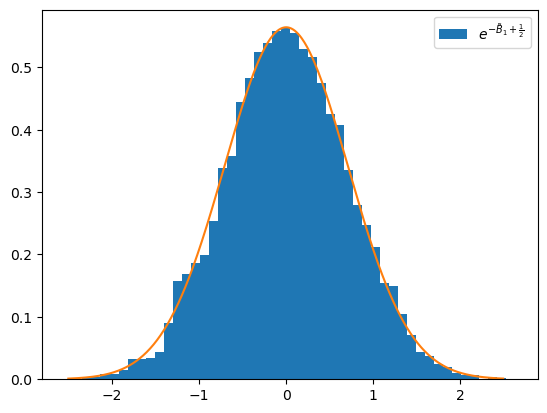

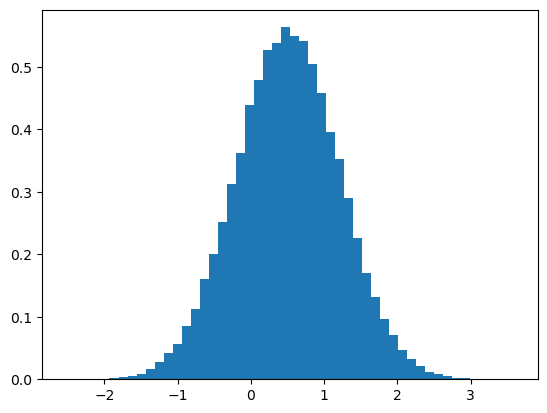

0.00828900154964653
0.7026412002029898
0.5016557224782967
0.7062404156471938
0.7071067811865476


In [1653]:
plug_in = np.arange(-2.5,2.5,diff)
plt.hist(S[:, 50], bins = 50, density=True, label=r"$e^{-\~B_1 + \frac{1}{2}}$")
plt.plot(plug_in, (1/m.sqrt(m.pi)) * np.exp(-(plug_in)**2))
plt.legend()
plt.show()

plt.hist(BM_tilde[:, 50], bins = 50, density=True)
plt.show()

print(np.mean(S[:, 50]))
print(np.std(S[:, 50]))
print(np.mean(BM_tilde[:, 50]))
print(np.std(BM_tilde[:, 50]))
print(m.sqrt(1/2))

### d

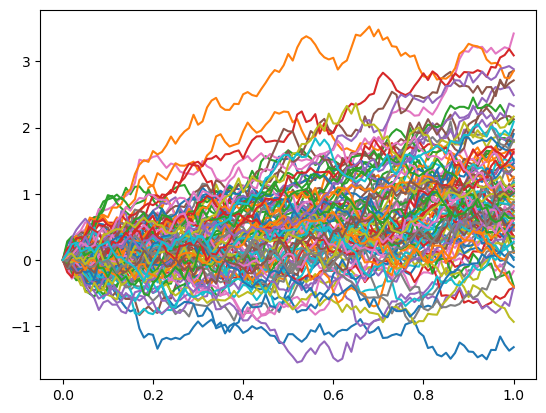

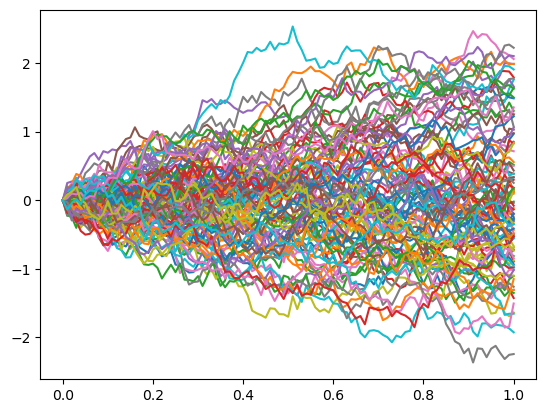

In [1654]:
plt.plot(x, BM_tilde[:100].T)
plt.show()

plt.plot(x, S[:100].T)
plt.show()

## 9.3

### a

In [1655]:
Y = np.zeros(shape=(100000, len(x)))

Y[:,0] = 0

Increments = np.random.normal(loc = 0, scale= m.sqrt(diff), size= (100000, len(x) - 1))

for i in range(len(x)- 1):
    Y[:,i+1] = Y[:,i] + (Increments[:,i] - (Y[:, i] * diff))

# plt.plot(x, Y.T)
# plt.show()

### b

In [1656]:
BM_integral = np.cumsum(np.insert(Y[:,:-1] * Increments,0,0, axis=1), axis=1)

RM_integral = np.cumsum(Y**2 * diff, axis=1)

M = np.exp(BM_integral - (1/2) * RM_integral)[:,-1]

print(M)

prop_sample = np.random.choice(100000, 50000, p= M/sum(M))

Y_sample = Y[prop_sample]

[1.72831566 0.84736069 0.6748721  ... 0.75704867 0.76724937 0.68945634]


### c

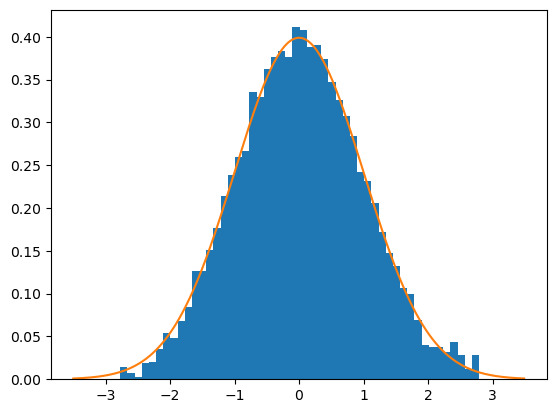

In [1657]:
plug_in = np.arange(-3.5,3.5,diff)
plt.hist(Y_sample[:,-1], bins=50, density=True)
plt.plot(plug_in, (1/m.sqrt(2 * m.pi)) * np.exp(-(plug_in)**2 / 2))
plt.show()

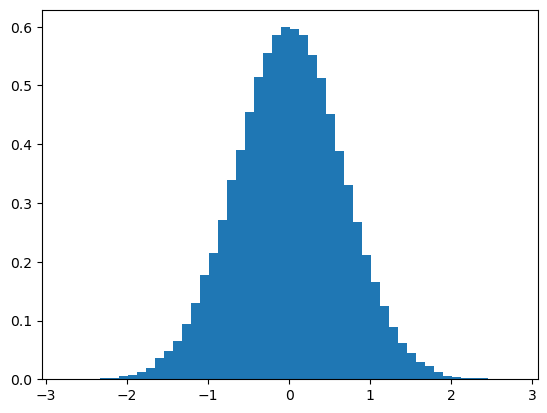

In [1658]:
plt.hist(Y[:,-1], bins = 50, density=True)
plt.show()

### d

In [1659]:
print(np.var(Y_sample[:, -1]))
print(np.var(Y[:,-1]))

0.9550662930033105
0.43455386538871343
